In [1]:
%matplotlib widget
import torch
import os
import copy
if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

import matplotlib.pyplot as plt

from diffSPH.operations import sph_operation, mod
from diffSPH.sampling import buildDomainDescription, sampleRegularParticles
from diffSPH.modules.eos import idealGasEOS
from diffSPH.modules.timestep import computeTimestep
from diffSPH.schema import getSimulationScheme
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.reference.sod import plotSod
# from diffSPH.reference.linear import buildLinearWaveSimulation, runLinearWaveTest
from diffSPH.enums import *
from diffSPH.reference.sod import plotSod

from scriptUtils import sampleRegionsSymmetric, mergeParticles, plotDomain, recreateUIDs
from diffSPH.schemes.states.compressiblesph import CompressibleState
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen

from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen
from diffSPH.sampling import generateNoiseInterpolator, sampleDivergenceFreeNoise


from diffSPH.modules.eos import idealGasEOS
from diffSPH.modules.compressible import CompressibleState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr

from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, SupportScheme

from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen
from diffSPH.io import initializeOutputFile, writeParticleData, writeParticleDataMinimal
import datetime
import matplotlib as mpl
from diffSPH.kernels import Kernel_xi
from diffSPH.util import postProcess



In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

nx = 200
dim = 2
kernel = KernelType.B7
targetNeighbors = n_h_to_nH(4, dim)
CFL = 0.3
goalRadius = 0.8

nx = 128
rho0 = 1
E0 = 1
gamma = 5/3

caseName = 'testCase'

scheme = SimulationScheme.CRKSPH
integrationScheme = IntegrationSchemeType.rungeKutta2
viscositySwitch = ViscositySwitch.NoneSwitch
supportScheme = AdaptiveSupportScheme.NoScheme

domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min = torch.tensor([-1, -1], device = device, dtype = dtype)
domain.max = torch.tensor([1, 1], device = device, dtype = dtype)

simulator, SimulationSystem, solverConfig, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     gamma, targetNeighbors, domain, 
     viscositySwitch=viscositySwitch, supportScheme = supportScheme)

L = 2
band = 0
solverConfig['particle'] = {
    'nx': nx + 2 * band,
    'dx': L/nx,
    'targetNeighbors': targetNeighbors,
    'band': band
}


Sampling regions with nx = [128, 128, 128, 128], splitX = [-0.5, 0.5], splitY = [-0.5, 0.5], jitter = 0.0


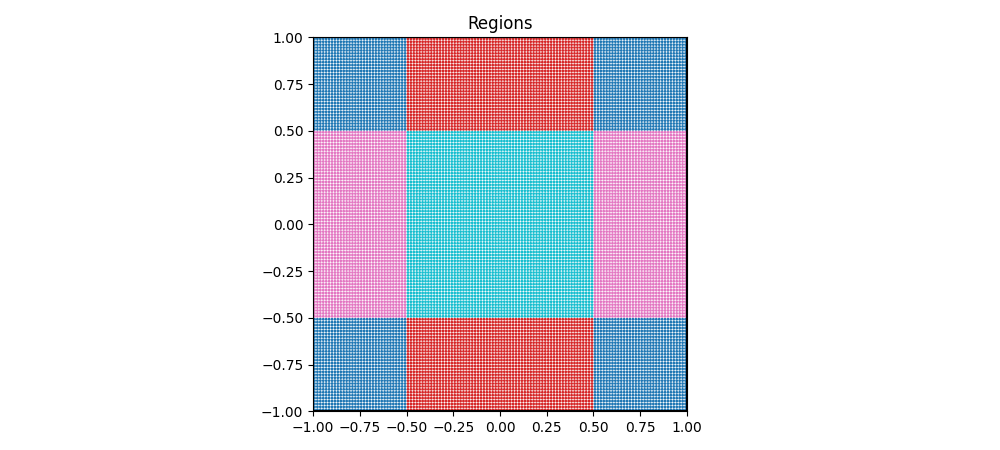

In [3]:
# splitLineX = -1+1/7
# splitLineY = -1/2
splitLineX = -1+1/2
splitLineY = -1/2

particlesA, particlesB, particlesC, particlesD, splitx, splity = sampleRegionsSymmetric(domain, [nx, nx, nx, nx], targetNeighbors, splitLineX, splitLineY)
particles, setIndex = mergeParticles([particlesA, particlesB, particlesC, particlesD])

# setIndex[:] = 0
# setIndex[torch.linalg.norm(particles.positions, dim=1) < 1/3] = 1
# setIndex[particles.positions[:, 0] < 0] = 1
# 
# setIndex[torch.logical_and(particles.positions[:,0].abs() < 1/3, particles.positions[:,1].abs() < 1/3)] = 1

fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)
axis[0,0].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), s = 4, marker = '.', c = setIndex.cpu(), cmap='tab10')
axis[0,0].set_title('Regions')

plotDomain(axis[0,0], domain)

fig.tight_layout()

tensor([0.9032, 0.8922, 0.8812,  ..., 0.1743, 0.1851, 0.1961], device='cuda:0')


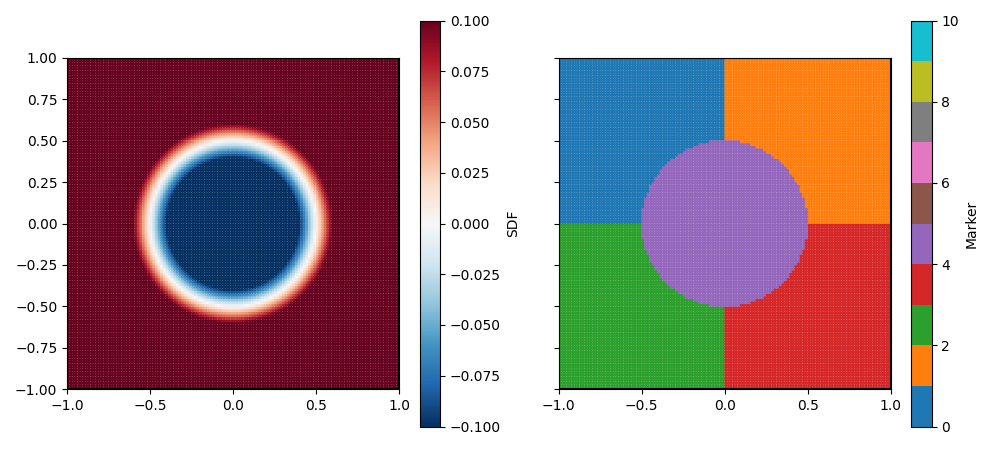

In [15]:
from scriptUtils import maskParticles_2


fig, axis = plt.subplots(1, 2, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)
setIndex, sdf_ = maskParticles_2(particles, 4, domain, nx, sdf = 'circle', sdfParameters = None, split_x = -0., split_y = 0.)
    

sc = axis[0,0].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), s = 8, marker = '.', c = sdf_.cpu(), cmap='RdBu_r', vmin = -0.1, vmax = 0.1)
fig.colorbar(sc, ax=axis[0,0], label='SDF')
sc = axis[0,1].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), s = 8, marker = '.', c = setIndex.cpu(), cmap='tab10', vmax = 10)
fig.colorbar(sc, ax=axis[0,1], label='Marker')

plotDomain(axis[0,0], domain)
plotDomain(axis[0,1], domain)

fig.tight_layout()

In [16]:
Pinitial = torch.ones_like(particles.positions[:, 0], device=device, dtype=dtype) * 1.0
rho = torch.ones_like(particles.positions[:, 0], device=device, dtype=dtype) * rho0

masses = particles.masses.clone()
m0 = torch.sum(masses) / particles.positions.shape[0]

# Pinitial[setIndex == 0] = 1.0
# masses[setIndex == 0] = m0
# rho[setIndex == 0] = rho0

# Pinitial[setIndex == 1] = 0.1
# masses[setIndex == 1] = 0.1 * m0
# rho[setIndex == 1] = 0.1 * rho0
# masses[setIndex == 1] = 4 * m0
# rho[setIndex == 1] = 4 * rho0

# Pinitial[setIndex == 2] = 1.0
# masses[setIndex == 2] =  m0
# rho[setIndex == 2] = rho0

# Pinitial[setIndex == 3] = 0.1
# masses[setIndex == 3] = m0
# rho[setIndex == 3] = rho0

import numpy as np


numberOfRegions = int(setIndex.max().item() + 1)
Pinitials = np.random.uniform(0.1, 2.0, size = (numberOfRegions,))
rhoInitials = np.random.uniform(0.1, 2.0, size = (numberOfRegions,))

for i in range(numberOfRegions):
    Pinitial[setIndex == i] = Pinitials[i]
    rho[setIndex == i] = rhoInitials[i] * rho0
    masses[setIndex == i] = rhoInitials[i] * m0


# Pinitial[setIndex == 3] = 0.1795
# rho[setIndex == 3] = 0.25
# particles = particles._replace(masses = torch.where(setIndex == 3, particles.masses / 4.0, particles.masses))

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = rho, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)


simulationState = CompressibleState(
    positions = particles.positions,
    supports = particles.supports,
    masses = masses,
    densities = rho,        
    velocities = torch.zeros_like(particles.positions, device = device, dtype = dtype),
    
    kinds = torch.zeros_like(particles.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles.positions[:,0], dtype = torch.int32),
    UIDs = recreateUIDs(particles, domain, verbose=False),

    internalEnergies = u_,
    totalEnergies = None,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(rho),
    alpha0s = torch.ones_like(rho)
)

# simulationState.velocities[setIndex == 3,0] = 1

In [17]:

octaves = 2
lacunarity = 2
persistence = 0.5
baseFrequency = 4
tileable = True
kind = 'perlin'
seed = 4235

noiseGen = generateNoiseInterpolator(nx, nx, domain, dim = domain.dim, octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)
velocityField = sampleDivergenceFreeNoise(simulationState, domain, solverConfig, nx, octaves, lacunarity, persistence, baseFrequency, tileable, kind, seed)
# simulationState.velocities = velocityField

noiseField = noiseGen(simulationState.positions).to(dtype)

# simulationState.masses = m0 + m0 * 0.75 * noiseField
# Pinitial = Pinitial + Pinitial * 0.75 * noiseField

# fig, axis = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False, sharex=True, sharey=True)
# _ = visualizeParticles(fig, axis[0,0], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.x', gridVisualization = True, quantity = velocityField[:,0])
# _ = visualizeParticles(fig, axis[0,1], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.y', gridVisualization = True, quantity = velocityField[:,1])
# _ = visualizeParticles(fig, axis[0,2], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = 'L2', gridVisualization = True, quantity = velocityField, streamLines = True)

# fig.tight_layout()

In [18]:
# from diffSPH.util import getPeriodicPositions
# import numpy as np
# from diffSPH.regions import buildRegion
# from diffSPH.boundary import sampleDomainSDF

# xi = 1
# noiseLevel = 0.01
# k = 5
# L = 2

# def forcing(x, mask, state, t, dt):
#     pos = getPeriodicPositions(x, domain)
#     noiseOffset = torch.rand(pos.shape[1], device = device, dtype = dtype) * L - L/2
#     noisePos = getPeriodicPositions(x + noiseOffset, domain)
#     u_x = xi * torch.sin(k * np.pi * pos[:,1])
#     u_y = noiseGen(pos.detach().cpu()).to(dtype = x.dtype, device = x.device) * noiseLevel
#     return torch.stack([u_x, u_y], dim = 1)

# fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)

# regions = []
# regions.append(buildRegion(sdf = fluid_sdf, config = solverConfig, type = 'forcing', dirichletValues={'velocities': forcing}))

# solverConfig['regions'] = regions

In [19]:
# import numpy as np

# u_mag = 1

# k_ = 2

# ktgv = k_ / 2
# if k_ % 2 == 0:
#     phaseShift_x = np.pi / 2# / k
#     phaseShift_y = np.pi / 2# / k
# else:
#     phaseShift_x = 0
#     phaseShift_y = 0

# simulationState.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * simulationState.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * simulationState.positions[:,1] + phaseShift_y)
# simulationState.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * simulationState.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * simulationState.positions[:,1] + phaseShift_y)


In [20]:
simulationState.masses

tensor([1.9671e-04, 1.9671e-04, 1.9671e-04,  ..., 6.3641e-05, 6.3641e-05,
        6.3641e-05], device='cuda:0')

In [21]:
neighborhood, neighbors = evaluateNeighborhood(simulationState, domain, kernel, verletScale = 1.4, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(neighborhood.fullAdjacency).rowEntries
numNeighbors = coo_to_csr(filterNeighborhoodByKind(simulationState, neighbors.neighbors, which = 'noghost')).rowEntries
densities = computeDensity(simulationState, kernel, neighbors.get('noghost'), SupportScheme.Gather, solverConfig)
print(densities.min(), densities.max(), densities.mean())
simulationState.densities = densities

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = simulationState.densities, gamma = gamma)

simulationState.internalEnergies = u_


particleSystem = SimulationSystem(
        systemState = simulationState,
        domain = domain,
        neighborhoodInfo = neighborhood,
        t = 0
    )

timeLimit = 4
dt = computeTimestep(scheme, 1e-3, particleSystem.systemState, solverConfig, None)
# dt = torch.tensor(1e-4, dtype = dtype, device = device)
timesteps = int(timeLimit / dt)
actualState = copy.deepcopy(particleSystem)

tensor(0.2607, device='cuda:0') tensor(1.2890, device='cuda:0') tensor(0.6568, device='cuda:0')


In [22]:
import math

dt = 1e-3
fps = 50
exportInterval = 1 / fps
exportSteps = int(math.ceil(exportInterval / dt))
newDt = exportInterval / exportSteps
plotInterval = int(math.floor(exportInterval / newDt))
plotInterval = min(max(plotInterval,1), 1000)
# print(f'Export Interval: {exportInterval}, Export Steps: {exportSteps}')
# print(f'Current dt: {dt}')
# print(f'Plot Interval: {plotInterval}')
# print(f'export Steps: {exportSteps}')
# print(f'New dt: {newDt}')

timesteps = int(timeLimit / newDt)
currentTime = datetime.datetime.now()
timestamp = currentTime.strftime("%Y-%m-%d_%H-%M-%S")

imagePrefix = f'./images/{caseName}{nx**2}_{timestamp}/'
exportName = f'./data/{caseName}_{nx**2}_{timestamp}.h5'
os.makedirs(os.path.dirname(exportName), exist_ok = True)
os.makedirs(imagePrefix, exist_ok = True)



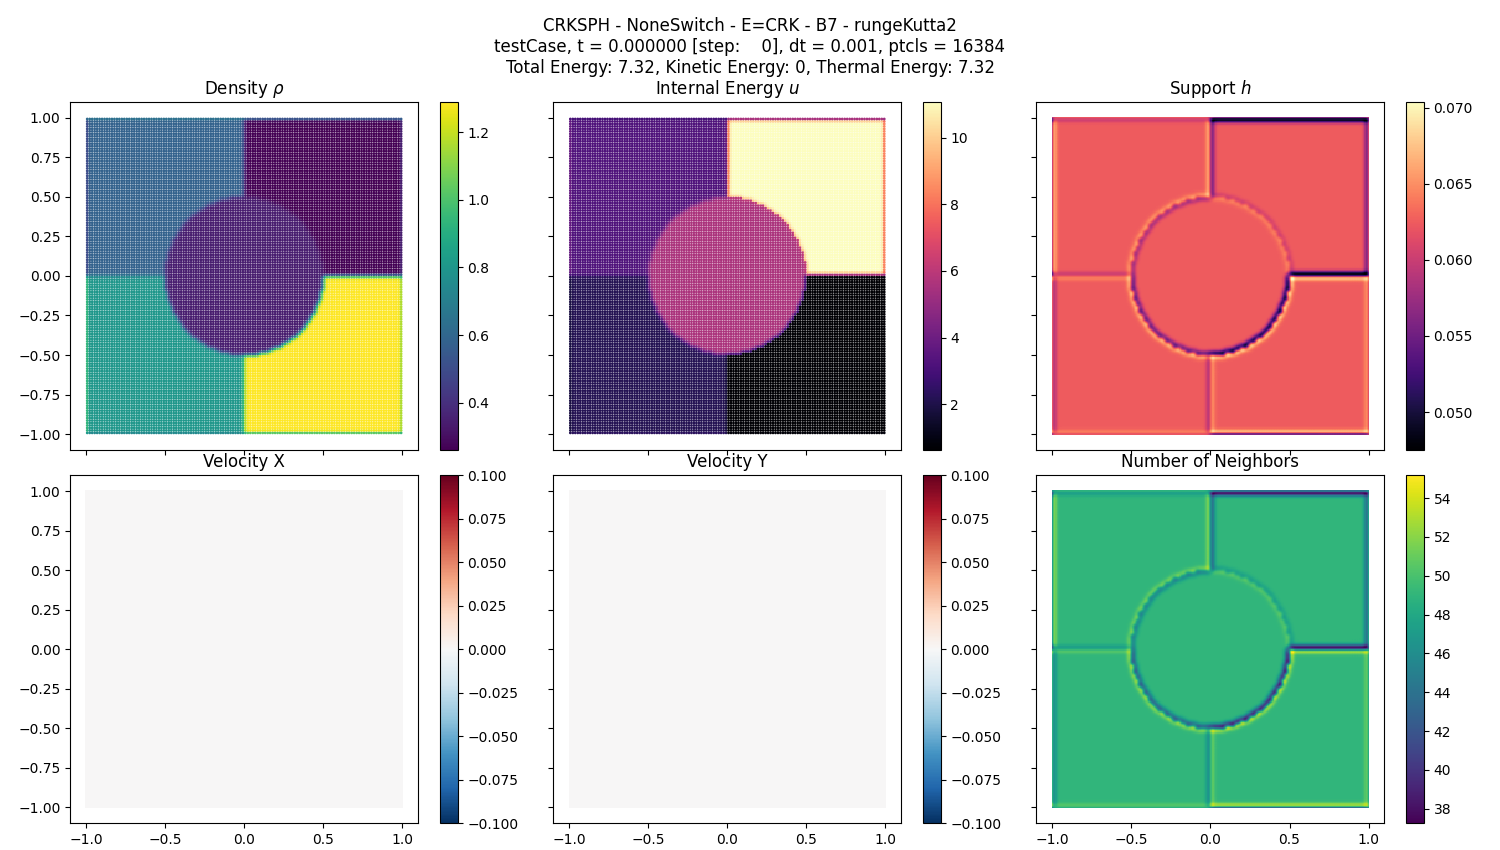

In [23]:
def plotScalar(fig, axis, label, fluidParticles, quantity, domain, solverConfig, s, gridVisualization=True, gridResolution=256, mapping = None, cmap = 'viridis'):
    return visualizeParticles(fig, axis,
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = quantity, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                    #  scaling = 'sym',
                     cmap = cmap,
                     midPoint=1.5,
                     mapping = mapping,
                     title=label,
                     markerSize = s,
                     gridVisualization=gridVisualization, gridResolution=gridResolution)


fig, axis = plt.subplots(2, 3, figsize=(15, 8.5), squeeze=False, sharex=True, sharey=True)

s = 1
fluidParticles = actualState.systemState


densityPlotState        = plotScalar(fig, axis[0,0], 'Density $\\rho$',     fluidParticles, densities,           domain, solverConfig, s, gridVisualization=False, gridResolution=256, cmap = 'viridis', mapping = None)
internalEnergyPlotState = plotScalar(fig, axis[0,1], 'Internal Energy $u$', fluidParticles, fluidParticles.internalEnergies,    domain, solverConfig, s, gridVisualization=False, gridResolution=256, cmap = 'magma', mapping = None)
supportPlotState        = plotScalar(fig, axis[0,2], 'Support $h$',         fluidParticles, fluidParticles.supports,            domain, solverConfig, s, gridVisualization=True, gridResolution=256, cmap = 'magma', mapping = None)
numNeighborsPlotState   = plotScalar(fig, axis[1,2], 'Number of Neighbors', fluidParticles, numNeighbors,                       domain, solverConfig, s, gridVisualization=True, gridResolution=256, mapping = '.y', cmap = 'viridis')
velocityXPlotState      = plotScalar(fig, axis[1,0], 'Velocity X',          fluidParticles, fluidParticles.velocities,          domain, solverConfig, s, gridVisualization=True, gridResolution=256, mapping = '.x', cmap = 'RdBu_r')
velocityYPlotState      = plotScalar(fig, axis[1,1], 'Velocity Y',          fluidParticles, fluidParticles.velocities,          domain, solverConfig, s, gridVisualization=True, gridResolution=256, mapping = '.y', cmap = 'RdBu_r')

# for ax in axis.flatten():
    # ax.set_xlim(-1, 1)
    # ax.set_ylim(-1,1)
kineticEnergy = 0.5 * (torch.linalg.norm(actualState.systemState.velocities, dim = -1) **2 * actualState.systemState.masses).sum()
thermalEnergy = (actualState.systemState.internalEnergies * actualState.systemState.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy


fig.suptitle(f'{solverConfig["schemeName"]}\n{caseName}, t = {actualState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(actualState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
# fig.suptitle(f'{solverConfig["schemeName"]}\nSedov-Taylor Explosion, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')

fig.tight_layout()

# fig.savefig(f'{imagePrefix}frame_{0:05d}.png', dpi = 100)


In [24]:
# outFile = initializeOutputFile(exportName, actualState, solverConfig,simulationName='testData')
# outGroup = outFile['simulationData']
# writeParticleData(outGroup, actualState, step = 0, dt = newDt)

In [25]:

states = []
dt = newDt
actualState.systemState.divergence = torch.zeros_like(actualState.systemState.densities)
for i in (tq:=tqdm(range(timesteps))):
# while(True):
    actualState, currentState, updates = integrator.function(actualState, dt, simulator, solverConfig, priorStep = actualState.priorStep)
    actualState.priorStep = [updates[-1], currentState[-1]]
    # if i%100 == 0:
        # states.append(copy.deepcopy(simulationState).to(dtype = torch.float32, device = 'cpu'))

    kineticEnergy = 0.5 * (torch.linalg.norm(actualState.systemState.velocities, dim = -1) **2 * actualState.systemState.masses).sum()
    thermalEnergy = (actualState.systemState.internalEnergies * actualState.systemState.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    tq.set_postfix({
        'Kinetic Energy': kineticEnergy.item(),
        'Thermal Energy': thermalEnergy.item(),
        'Total Energy': totalEnergy.item(),
        'Time': actualState.t.item() if torch.is_tensor(actualState.t) else actualState.t,
    })

    c_s = idealGasEOS(A=None, P = None, u = actualState.systemState.internalEnergies, rho = actualState.systemState.densities, gamma = solverConfig['fluid']['gamma'])[-1]
    c_s_max = c_s.max()
    h_min = actualState.systemState.supports.min()
    xi = Kernel_xi(solverConfig['kernel'], actualState.systemState.positions.shape[1])

    # xi = solverConfig['kernel'].xi(particles.positions.shape[1])
    # CFL = 0.3
    timestepCFL = 0.3
    dt_cfl = timestepCFL * h_min / (c_s_max * xi)
    CFLNumber = (c_s_max * xi * dt) / h_min
    
    print(f'Current dt: {dt:.3g}, CFL dt: {dt_cfl:.3g}, h_min: {h_min:.3g}, c_s_max: {c_s_max:.3g}, xi: {xi:.3g}')


    # frameGroup = writeParticleDataMinimal(outGroup, actualState, step = i+1, dt = dt)

    # frameGroup.attrs['timestepCFL'] = timestepCFL
    # frameGroup.attrs['CFLNumber'] = CFLNumber.item() if torch.is_tensor(CFLNumber) else CFLNumber
    # frameGroup.attrs['c_s_max'] = c_s_max.item() if torch.is_tensor(c_s_max) else c_s_max
    # frameGroup.attrs['h_min'] = h_min.item() if torch.is_tensor(h_min) else h_min
    # frameGroup.attrs['xi'] = xi.item() if torch.is_tensor(xi) else xi
    # frameGroup.attrs['dt_cfl'] = dt_cfl.item() if torch.is_tensor(dt_cfl) else dt_cfl
    # frameGroup.attrs['kineticEnergy'] = kineticEnergy.item() if torch.is_tensor(kineticEnergy) else kineticEnergy
    # frameGroup.attrs['thermalEnergy'] = thermalEnergy.item() if torch.is_tensor(thermalEnergy) else thermalEnergy
    # frameGroup.attrs['totalEnergy'] = totalEnergy.item() if torch.is_tensor(totalEnergy) else totalEnergy

    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlotState, actualState.systemState, actualState.systemState.densities)
        updatePlot(internalEnergyPlotState, actualState.systemState, actualState.systemState.internalEnergies)
        updatePlot(supportPlotState, actualState.systemState, actualState.systemState.supports)


        neighborhood, neighbors = evaluateNeighborhood(actualState.systemState, solverConfig['domain'], solverConfig['kernel'], verletScale = solverConfig['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=actualState.neighborhoodInfo)
        numNeighbors = coo_to_csr(filterNeighborhoodByKind(actualState.systemState, neighbors.neighbors, which = 'noghost')).rowEntries
        updatePlot(numNeighborsPlotState, actualState.systemState, numNeighbors)

        # numNeighbors = coo_to_csr(filterNeighborhoodByKind(actualState.systemState, currentState[-1][1].fullAdjacency, which = 'noghost')).rowEntries
        # numNeighbors = coo_to_csr(currentState[-1][1].fullAdjacency).rowEntries

        updatePlot(velocityXPlotState, actualState.systemState, actualState.systemState.velocities)
        # for patch in axis[0,2].patches[:]:
        #     print(patch)
        #     if isinstance(patch, mpl.patches.FancyArrowPatch):
        #         patch.remove()
        updatePlot(velocityYPlotState, actualState.systemState, actualState.systemState.velocities)

        # for ax in axis.flatten():
            # ax.set_xlim(-1, 1)
            # ax.set_ylim(-1,1)

        fig.suptitle(f'{solverConfig["schemeName"]}\n{caseName}, t = {actualState.t:2f} [step: {i:4d}], dt = {dt:.3g}, ptcls = {len(actualState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')


        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePrefix}frame_{i:05d}.png', dpi = 100)

  0%|          | 0/4000 [00:00<?, ?it/s]

Namespace CRKSPH not found in config. Setting eta_crit to 0.25
Key eta_fold not found in config["CRKSPH"]. Setting eta_fold to 0.2
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0.0625, c_s_max: 3.51, xi: 3.93
Current dt: 0.001, CFL dt: 0.00136, h_min: 0

In [14]:
# outFile.close()

In [26]:

import os
import subprocess
import shlex
import imageio.v2 as imageio
from skimage.transform import resize, rescale
from skimage.io import imread


def postProcess(imagePrefix, fps, exportName, targetLongEdge = 600):
    fileList = os.listdir(imagePrefix)
    fileList = [f for f in fileList if f.endswith('.png') and f.startswith('frame_')]
    fileList = sorted(fileList)

    writer = imageio.get_writer(f'{imagePrefix}/output.mp4', fps=fps, bitrate='30M')
    for image in fileList:
        writer.append_data(imageio.imread(imagePrefix + image))
    writer.close()

    images = []
    for image in fileList:
        images.append(imread(imagePrefix + image))

    currentImageSize = images[0].shape
    currentLongEdge = max(images[0].shape[0], images[0].shape[1])
    ratio = targetLongEdge / currentLongEdge

    images = [(rescale(image, ratio, anti_aliasing=True, channel_axis=-1)*255).astype('uint8') for image in images]

    # for image in images:
        # print(image.shape)
        # break

    # images = [resizeImageLongEdge(i, 600) for i in images]

    imageio.mimsave(f'{imagePrefix}/output.gif', images, fps=fps, loop = 0)
    
    print('Copying video to videos folder')
    os.makedirs(f'./videos/', exist_ok= True)
    # subprocess.run(shlex.split(f'cp {imagePrefix}/output.mp4 ./videos/{exportName}.mp4'))
    subprocess.run(shlex.split(f'cp {imagePrefix}/output.gif ./videos/{exportName}.gif'))
    lastFrameFile = imagePrefix + fileList[-1]
    subprocess.run(shlex.split(f'cp {lastFrameFile} ./videos/{exportName}.png'))
    print('Done!')


postProcess(
    imagePrefix = imagePrefix,
    fps = 50,
    exportName = '2DShock2',
    targetLongEdge = 1200
)
# def postProcess(imagePrefix, fps, exportName, targetLongEdge = 600):

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 850) to (1504, 864) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Copying video to videos folder
Done!


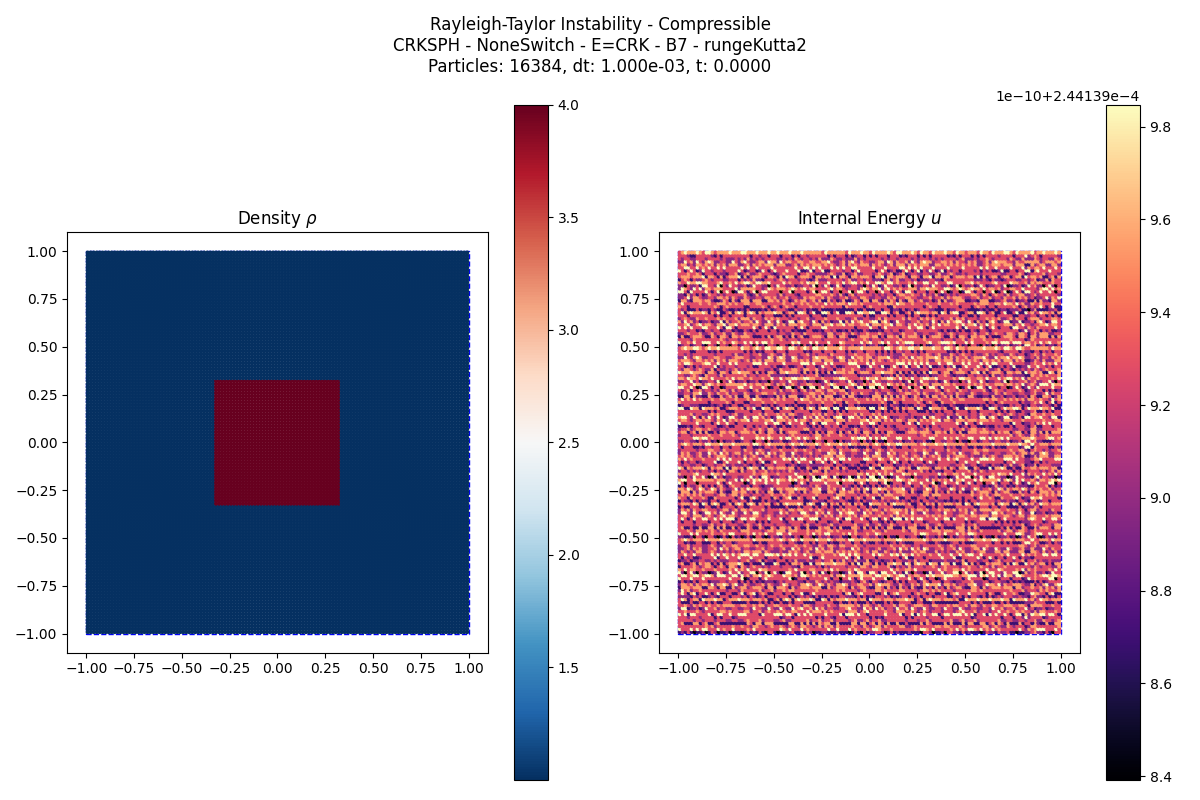

In [16]:
from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt

wrappedKernel = solverConfig['kernel']

particles = particleSystem.systemState
neighborhood, neighbors = evaluateNeighborhood(particles, domain, kernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particles.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
densities = computeDensity(particles, kernel, neighbors.get('noghost'), SupportScheme.Gather, solverConfig)

particles.omega = torch.ones_like(particles.masses)
particles.apparentArea = computeCRKVolume(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, solverConfig)

kernelMoments = computeGeometricMoments(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, solverConfig)

particles.A, particles.B, particles.gradA, particles.gradB = computeCRKTerms(kernelMoments, particles.numNeighbors, particles.supports)

densities = computeCRKDensity(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, solverConfig)
# fluidParticles = particleSystem.systemState
fig, axis = plt.subplots(1, 2, figsize = (12, 8), squeeze = False)

markerSize = 4
densityPlotState = visualizeParticles(fig, axis[0,0],
                     particles = particles, 
                     domain = domain, 
                     quantity = densities, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = True,
                     cmap = 'RdBu_r',
                     title='Density $\\rho$',
                     markerSize = markerSize,)

velocityPlotState = visualizeParticles(fig, axis[0,1],
                     particles = particles, 
                     domain = domain, 
                     quantity = particles.apparentArea, 
                     which = 'fluid',
                     mapping = 'L2',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = True,
                     cmap = 'magma',
                     title='Internal Energy $u$',
                     markerSize = markerSize,)

fig.suptitle(f"Rayleigh-Taylor Instability - Compressible\n{solverConfig['schemeName']}\nParticles: {fluidParticles.positions.shape[0]}, dt: {dt:1.3e}, t: {particleSystem.t:.4f}", fontsize=12)

# axis[0,0].set_ylim(-1,1)
# axis[0,1].set_ylim(-1,1)


fig.tight_layout()